# Food Allergen Filter - Evaluation Pipeline (OpenAI)
## Accuracy Testing & Metrics Calculation

This notebook runs the allergen detection system against test data and measures:
- Accuracy
- Precision & Recall
- F1-Score
- Confusion Matrix
- Detail Report

In [3]:
!pip install "langchain==0.2.17" "langchain-core==0.2.43" "langchain-openai==0.1.23" langchain-google-genai

     ---------------------------------------- 1.0/1.0 MB 6.4 MB/s eta 0:00:00
     ---------------------------------------- 397.1/397.1 kB ? eta 0:00:00
     ---------------------------------------- 52.0/52.0 kB ? eta 0:00:00
     ---------------------------------------- 311.8/311.8 kB ? eta 0:00:00
  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
     ------------------------------------- 948.6/948.6 kB 58.6 MB/s eta 0:00:00
  Using cached langchain_google_genai-4.2.1-py3-none-any.whl (66 kB)
     ---------------------------------------- 66.5/66.5 kB 3.7 MB/s eta 0:00:00
     ---------------------------------------- 66.3/66.3 kB 3.5 MB/s eta 0:00:00
     ---------------------------------------- 65.6/65.6 kB ? eta 0:00:00
     ---------------------------------------- 65.5/65.5 kB ? eta 0:00:00
     ---------------------------------------- 65.5/65.5 kB ? eta 0:00:00
     ---------------------------------------- 63.6/63.6 kB ? eta 0:00:00
     -----------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 1.26.4 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.14.1 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
langgraph 1.1.9 requires langchain-core<2,>=1.3.0, but you have langchain-core 0.2.43 which is incompatible.
langgraph-prebuilt 1.0.11 requires langchain-core>=1.3.1, but you have langchain-core 0.2.43 which is incompatible.
langchain-community 0.3.16 requires langchain<0.4.0,>=0.3.16, but you have langchain 0.2.17 which is incompatible.
langchain-community 0.3.16 requires langchain-core<0.4.0,>=0.3.32, but you have langchain-core 0.2.43 which is incompatib

In [2]:
!pip install -r requirements.txt


[notice] A new release of pip available: 22.2.1 -> 26.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [5]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from math import exp
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import os

In [8]:
load_dotenv()

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    logprobs=True
)

In [9]:
# Load test data from JSON
with open('test_data.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"โหลด Test Cases: {len(test_data['test_cases'])} cases")
print(f"Test cases แรก 3 ข้อ:")
for i in range(min(3, len(test_data['test_cases']))):
    case = test_data['test_cases'][i]
    print(f"\n  Case {case['id']}: {case['menu_data']['menu_name']}")
    print(f"  Ground Truth: {case['ground_truth']}")
    print(f"  Reason: {case['reason']}")

โหลด Test Cases: 100 cases
Test cases แรก 3 ข้อ:

  Case 1: ผัดไทยกุ้งสด
  Ground Truth: True
  Reason: มีกุ้งสดและถั่วลิสงคั่วเป็นส่วนผสมหลัก

  Case 2: ส้มตำไทย
  Ground Truth: False
  Reason: ส้มตำไทยปกติไม่มีปูเป็นส่วนผสม

  Case 3: ข้าวมันไก่
  Ground Truth: False
  Reason: ไม่มีผลิตภัณฑ์จากนมเป็นส่วนผสม


In [10]:
def check_allergy_system(menu_data, allergy_details):
    """ตรวจสอบความเสี่ยงจากสารก่อภูมิแพ้ (OpenAI Version)"""
    menu_name = menu_data.get("menu_name", "")
    menu_description = menu_data.get("menu_description", "")

    allergy_names = [
        item.get("allergy_name", "").strip()
        for item in allergy_details
        if item.get("allergy_name")
    ]

    prompt = f"""ตรวจสอบเมนูอาหารว่ามีความเสี่ยงต่อสารก่อภูมิแพ้หรือไม่

menu_name: {menu_name}
menu_description: {menu_description}
allergy_names: {json.dumps(allergy_names, ensure_ascii=False)}

ให้ตอบเป็น JSON เท่านั้นในรูปแบบนี้:
{{
  "is_risky": true หรือ false,
  "matched_allergy_names": ["ชื่อสารก่อภูมิแพ้ที่พบ"],
  "self_check": {{
    "is_consistent": true หรือ false,
    "reason": "เหตุผลสั้นๆ กระชับ"
  }}
}}"""

    response = llm.invoke([HumanMessage(content=prompt)])

    try:
        parsed = json.loads(response.content)
    except json.JSONDecodeError:
        parsed = {
            "is_risky": False,
            "matched_allergy_names": [],
            "self_check": {"is_consistent": False, "reason": "parse JSON ไม่สำเร็จ"},
        }

    try:
        logprob_data = response.response_metadata.get("logprobs", {}).get("content", [])
        if logprob_data:
            chosen_logprob = logprob_data[0]["logprob"]
            confidence = exp(chosen_logprob)
        else:
            confidence = -1.0
    except (KeyError, IndexError, TypeError):
        confidence = -1.0

    matched_names = [name.strip() for name in parsed.get("matched_allergy_names", []) if isinstance(name, str)]

    matched_allergies = [
        {
            "allergy_id": item.get("allergy_id"),
            "allergy_name": item.get("allergy_name"),
            "count": item.get("count", 1),
        }
        for item in allergy_details
        if item.get("allergy_name") in matched_names
    ]

    if 0.1 <= confidence <= 0.8:
        status = "MANUAL_REVIEW"
    elif bool(parsed.get("is_risky")):
        status = "ALLERGY_WARN"
    else:
        status = "SAFE"

    self_check = parsed.get("self_check", {}) if isinstance(parsed, dict) else {}
    reason = ""
    if isinstance(self_check, dict):
        reason = str(self_check.get("reason", "")).strip()

    return {
        "menu_name": menu_name,
        "menu_description": menu_description,
        "matched_allergies": matched_allergies,
        "confidence": f"{confidence:.2%}" if confidence >= 0 else "N/A",
        "status": status,
        "is_risky": bool(parsed.get("is_risky")),
        "raw_llm": response.content,
        "reason": reason,
    }

print("✅ Function check_allergy_system ready")

✅ Function check_allergy_system ready


In [18]:
# === Configuration ===
# คุณสามารถเลือก mode:
# - 'sample': รัน 10 test cases แรก (ประหยัด API)
# - 'full': รันทั้งหมด
# - 'range': ระบุช่วง เช่น (0, 20) สำหรับ 20 cases

RUN_MODE = 'full'  # เปลี่ยนเป็น 'full' เมื่อพร้อม

if RUN_MODE == 'sample':
    test_cases = test_data['test_cases'][:10]
elif RUN_MODE == 'full':
    test_cases = test_data['test_cases']
else:
    start, end = 0, 20  # ระบุช่วงที่ต้องการ
    test_cases = test_data['test_cases'][start:end]

print(f"Mode: {RUN_MODE}")
print(f"จำนวน Test Cases ที่จะรัน: {len(test_cases)}")

Mode: full
จำนวน Test Cases ที่จะรัน: 100


In [19]:
# === Run Evaluation ===
results = []

print("\n🔄 กำลังรันการทดสอบ...\n")

for idx, test_case in enumerate(test_cases, 1):
    case_id = test_case['id']
    menu_data = test_case['menu_data']
    allergy_details = test_case['allergy_details']
    ground_truth = test_case['ground_truth']
    
    print(f"[{idx}/{len(test_cases)}] Case {case_id}: {menu_data['menu_name'][:30]}...", end="")
    
    try:
        ai_result = check_allergy_system(menu_data, allergy_details)
        ai_prediction = ai_result['is_risky']
        
        # Mark correctness
        is_correct = (ai_prediction == ground_truth)
        
        results.append({
            'case_id': case_id,
            'menu_name': menu_data['menu_name'],
            'allergies': ', '.join([a['allergy_name'] for a in allergy_details]),
            'ground_truth': ground_truth,
            'ai_prediction': ai_prediction,
            'confidence': ai_result['confidence'],
            'status': ai_result['status'],
            'is_correct': is_correct,
            'reason': test_case['reason']
        })
        
        status_symbol = "✓" if is_correct else "✗"
        print(f" {status_symbol} [GT: {ground_truth} → AI: {ai_prediction}] Conf: {ai_result['confidence']}")
        
    except Exception as e:
        print(f" ❌ ERROR: {str(e)[:50]}")
        results.append({
            'case_id': case_id,
            'menu_name': menu_data['menu_name'],
            'allergies': ', '.join([a['allergy_name'] for a in allergy_details]),
            'ground_truth': ground_truth,
            'ai_prediction': None,
            'confidence': 'ERROR',
            'status': 'ERROR',
            'is_correct': False,
            'reason': str(e)[:100]
        })

print("\n✅ ทำการทดสอบเสร็จแล้ว")


🔄 กำลังรันการทดสอบ...

[1/100] Case 1: ผัดไทยกุ้งสด... ✓ [GT: True → AI: True] Conf: 90.46%
[2/100] Case 2: ส้มตำไทย... ✓ [GT: False → AI: False] Conf: 73.11%
[3/100] Case 3: ข้าวมันไก่... ✓ [GT: False → AI: False] Conf: 88.08%
[4/100] Case 4: สปาเก็ตตี้คาโบนาร่า... ✓ [GT: True → AI: True] Conf: 90.47%
[5/100] Case 5: ต้มยำกุ้งน้ำข้น... ✓ [GT: True → AI: True] Conf: 92.41%
[6/100] Case 6: แกงเขียวหวานไก่... ✓ [GT: False → AI: False] Conf: 67.92%
[7/100] Case 7: พิซซ่าฮาวายเอี้ยน... ✓ [GT: True → AI: True] Conf: 92.41%
[8/100] Case 8: ยำวุ้นเส้นทะเล... ✓ [GT: True → AI: True] Conf: 95.26%
[9/100] Case 9: ข้าวผัดหมู... ✓ [GT: False → AI: False] Conf: 88.08%
[10/100] Case 10: ซุปเห็ดทรัฟเฟิล... ✓ [GT: True → AI: True] Conf: 93.99%
[11/100] Case 11: สเต็กปลาแซลมอน... ✓ [GT: True → AI: True] Conf: 96.27%
[12/100] Case 12: หมูสเต๊ะ... ✓ [GT: True → AI: True] Conf: 93.99%
[13/100] Case 13: แซนวิชทูน่า... ✓ [GT: True → AI: True] Conf: 93.99%
[14/100] Case 14: กะเพราเนื้อสับ... ✓ [GT: False → 

In [20]:
# === Convert to DataFrame for analysis ===
results_df = pd.DataFrame(results)

# Filter valid results (no errors)
valid_results = results_df[results_df['is_correct'].notna()]

print("\n" + "="*70)
print("📊 EVALUATION RESULTS")
print("="*70)

# Ground truth and predictions
y_true = valid_results['ground_truth'].values
y_pred = valid_results['ai_prediction'].values

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"\n📈 Key Metrics:")
print(f"  • Accuracy  (ถูกทั้งหมด):     {accuracy:.2%}")
print(f"  • Precision (ถูกเมื่อบอกเสี่ยง): {precision:.2%}")
print(f"  • Recall    (เจอเสี่ยงได้ทั้งหมด): {recall:.2%}")
print(f"  • F1-Score  (ความสมดุล):      {f1:.2%}")

# Count results
correct = valid_results['is_correct'].sum()
total = len(valid_results)
print(f"\n✅ ถูก: {correct}/{total} ({correct/total:.2%})")
print(f"❌ ผิด: {total - correct}/{total} ({(total-correct)/total:.2%})")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\n🔍 Confusion Matrix:")
print(f"          Predicted False  Predicted True")
print(f"Actual False    {cm[0][0]:3d}           {cm[0][1]:3d}")
print(f"Actual True     {cm[1][0]:3d}           {cm[1][1]:3d}")


📊 EVALUATION RESULTS

📈 Key Metrics:
  • Accuracy  (ถูกทั้งหมด):     98.00%
  • Precision (ถูกเมื่อบอกเสี่ยง): 100.00%
  • Recall    (เจอเสี่ยงได้ทั้งหมด): 97.14%
  • F1-Score  (ความสมดุล):      98.55%

✅ ถูก: 98/100 (98.00%)
❌ ผิด: 2/100 (2.00%)

🔍 Confusion Matrix:
          Predicted False  Predicted True
Actual False     30             0
Actual True       2            68


In [21]:
# === Detailed Classification Report ===
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT (ละเอียด)")
print("="*70)
print(classification_report(y_true, y_pred, target_names=['SAFE (False)', 'RISKY (True)'], digits=3))


📋 CLASSIFICATION REPORT (ละเอียด)
              precision    recall  f1-score   support

SAFE (False)      0.938     1.000     0.968        30
RISKY (True)      1.000     0.971     0.986        70

    accuracy                          0.980       100
   macro avg      0.969     0.986     0.977       100
weighted avg      0.981     0.980     0.980       100



In [22]:
# === Show Error Cases ===
error_cases = valid_results[~valid_results['is_correct']]

print("\n" + "="*70)
print(f"❌ INCORRECT CASES: {len(error_cases)} cases")
print("="*70)

if len(error_cases) > 0:
    for idx, (_, row) in enumerate(error_cases.iterrows(), 1):
        print(f"\n{idx}. {row['menu_name']}")
        print(f"   Allergy: {row['allergies']}")
        print(f"   Ground Truth: {row['ground_truth']} → AI Predicted: {row['ai_prediction']}")
        print(f"   Confidence: {row['confidence']}")
        print(f"   Expected Reason: {row['reason']}")
else:
    print("\n✨ ไม่มีข้อผิดพลาด! AI ตอบถูกทุกข้อ")


❌ INCORRECT CASES: 2 cases

1. แกงเผ็ดเป็ดย่าง
   Allergy: กุ้ง
   Ground Truth: True → AI Predicted: False
   Confidence: 85.20%
   Expected Reason: พริกแกงเผ็ดโดยทั่วไปมีส่วนผสมของกะปิที่ทำมาจากกุ้ง

2. ข้าวซอยเนื้อ
   Allergy: ไข่
   Ground Truth: True → AI Predicted: False
   Confidence: 77.73%
   Expected Reason: เส้นบะหมี่ข้าวซอยส่วนใหญ่เป็นบะหมี่ไข่


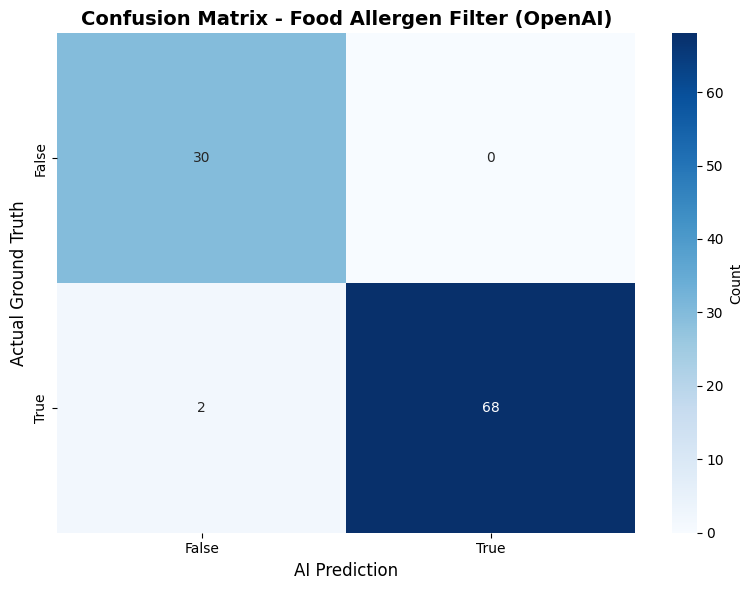

✅ Confusion Matrix saved to confusion_matrix_openai.png


In [23]:
# === Visualization: Confusion Matrix ===
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['False', 'True'],
            yticklabels=['False', 'True'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Food Allergen Filter (OpenAI)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Ground Truth', fontsize=12)
plt.xlabel('AI Prediction', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_openai.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Confusion Matrix saved to confusion_matrix_openai.png")

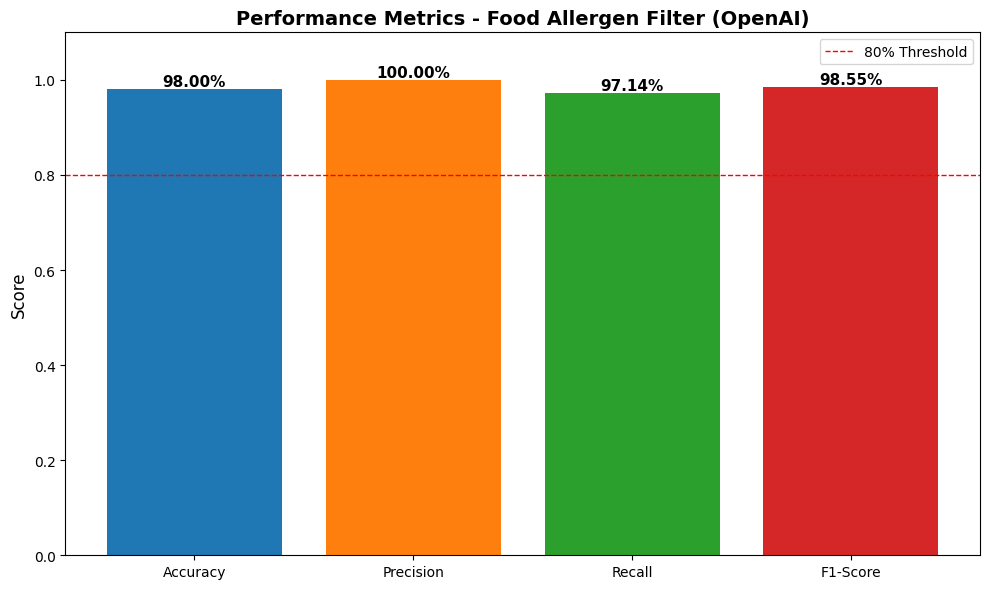

✅ Metrics Chart saved to metrics_chart_openai.png


In [24]:
# === Visualization: Metrics Bar Chart ===
metrics_data = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics_data.keys(), metrics_data.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics - Food Allergen Filter (OpenAI)', fontsize=14, fontweight='bold')
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=1, label='80% Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('metrics_chart_openai.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Metrics Chart saved to metrics_chart_openai.png")

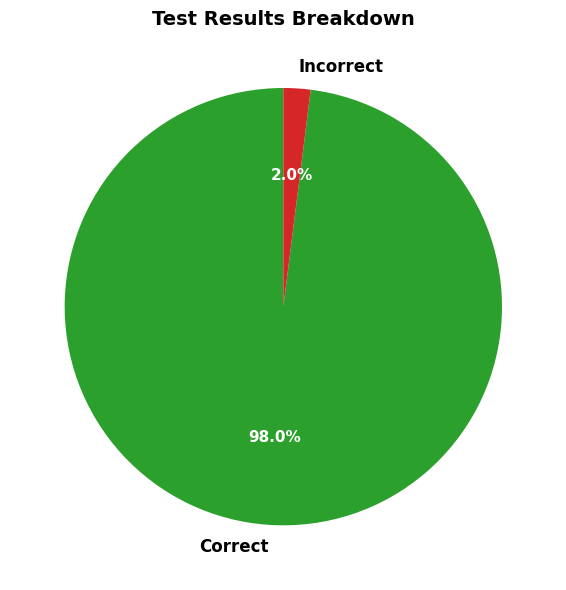

✅ Result Breakdown chart saved to result_breakdown_openai.png


In [25]:
# === Visualization: Result Breakdown (Pie Chart) ===
result_counts = {
    'Correct': correct,
    'Incorrect': total - correct
}

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ca02c', '#d62728']
wedges, texts, autotexts = ax.pie(result_counts.values(), labels=result_counts.keys(), autopct='%1.1f%%',
                                    colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

ax.set_title('Test Results Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('result_breakdown_openai.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Result Breakdown chart saved to result_breakdown_openai.png")

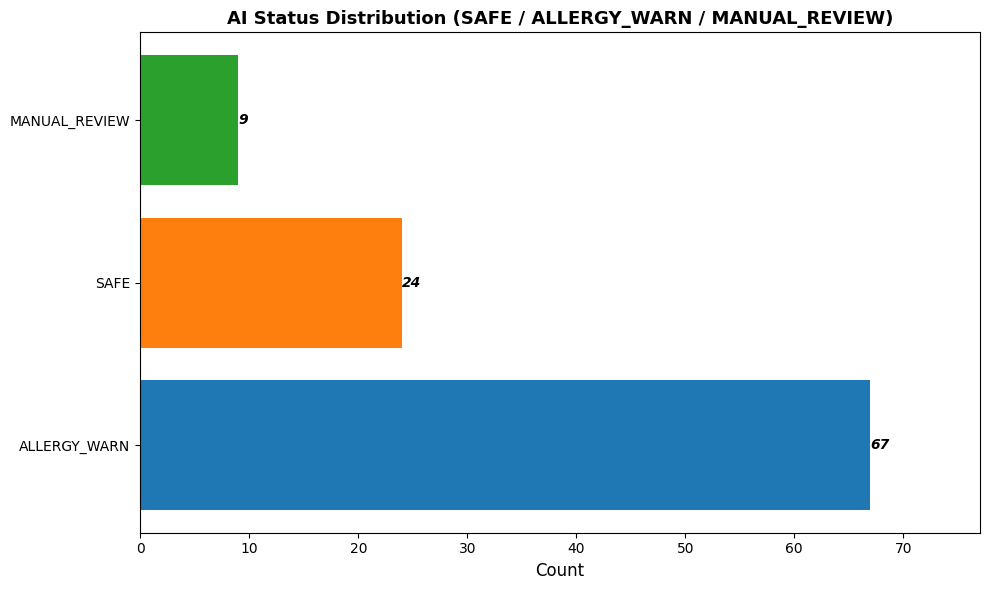

✅ Status Distribution chart saved to status_distribution_openai.png


In [26]:
# === Visualization: Status Distribution ===
status_counts = valid_results['status'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(status_counts.index, status_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f'{int(width)}',
            ha='left', va='center', fontsize=10, fontweight='bold', style='italic')

ax.set_xlabel('Count', fontsize=12)
ax.set_title('AI Status Distribution (SAFE / ALLERGY_WARN / MANUAL_REVIEW)', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(status_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('status_distribution_openai.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Status Distribution chart saved to status_distribution_openai.png")

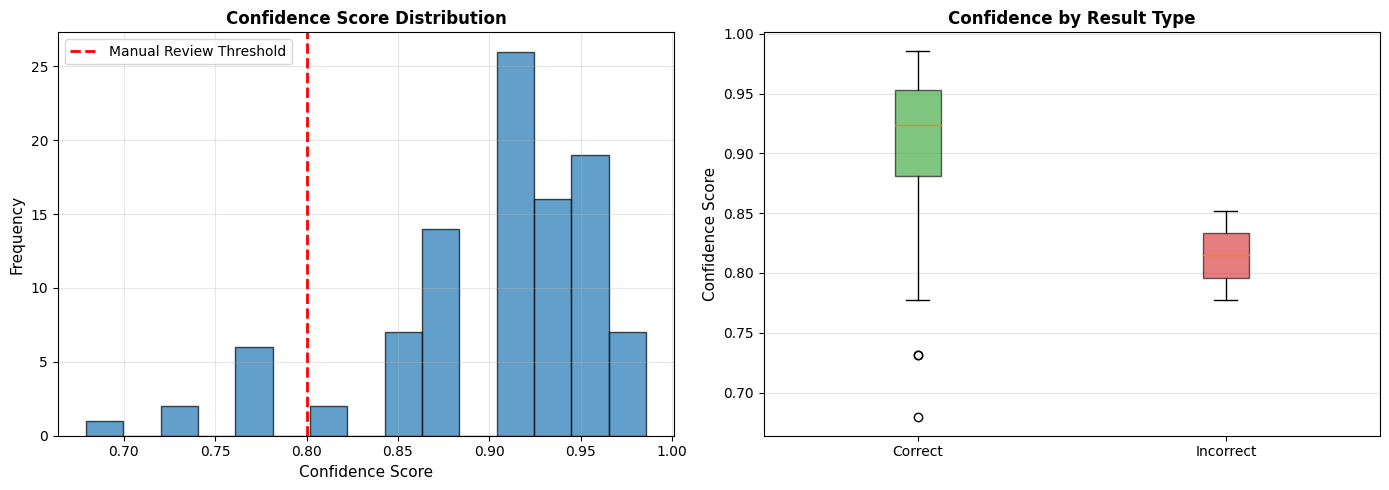

✅ Confidence Distribution chart saved to confidence_distribution_openai.png


In [27]:
# === Visualization: Confidence Score Distribution ===
# Extract numeric confidence values
confidence_values = []
for conf_str in valid_results['confidence']:
    try:
        # Remove % and convert to float
        if conf_str != 'N/A' and conf_str != 'ERROR':
            conf_num = float(conf_str.rstrip('%')) / 100
            confidence_values.append(conf_num)
    except:
        pass

if confidence_values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(confidence_values, bins=15, color='#1f77b4', edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Manual Review Threshold')
    axes[0].set_xlabel('Confidence Score', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Confidence Score Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot by correctness
    correct_conf = [float(conf.rstrip('%'))/100 for conf, correct in zip(valid_results['confidence'], valid_results['is_correct']) 
                   if conf != 'N/A' and conf != 'ERROR' and correct]
    incorrect_conf = [float(conf.rstrip('%'))/100 for conf, correct in zip(valid_results['confidence'], valid_results['is_correct']) 
                     if conf != 'N/A' and conf != 'ERROR' and not correct]
    
    box_data = [correct_conf, incorrect_conf]
    bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], ['#2ca02c', '#d62728']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    axes[1].set_ylabel('Confidence Score', fontsize=11)
    axes[1].set_title('Confidence by Result Type', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('confidence_distribution_openai.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("✅ Confidence Distribution chart saved to confidence_distribution_openai.png")
else:
    print("⚠️  No confidence data available for visualization")

In [28]:
# === Export Results to CSV ===
results_df.to_csv('evaluation_results_openai.csv', index=False, encoding='utf-8-sig')
print("✅ Results exported to evaluation_results_openai.csv")

# === Export Summary Report ===
summary_report = f"""FOOD ALLERGEN FILTER - EVALUATION REPORT (OpenAI)
{'='*70}

Run Mode: {RUN_MODE.upper()}
Test Cases Evaluated: {len(valid_results)}
Model: GPT-4o-mini

OVERALL PERFORMANCE:
  Accuracy:  {accuracy:.2%}
  Precision: {precision:.2%}
  Recall:    {recall:.2%}
  F1-Score:  {f1:.2%}

RESULT BREAKDOWN:
  Correct:   {correct}/{total} ({correct/total:.2%})
  Incorrect: {total - correct}/{total} ({(total-correct)/total:.2%})

CONFUSION MATRIX:
          Predicted False  Predicted True
Actual False    {cm[0][0]:3d}           {cm[0][1]:3d}
Actual True     {cm[1][0]:3d}           {cm[1][1]:3d}

{'='*70}
Report generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open('evaluation_summary_openai.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("✅ Summary report saved to evaluation_summary_openai.txt")
print("\n" + summary_report)

✅ Results exported to evaluation_results_openai.csv
✅ Summary report saved to evaluation_summary_openai.txt

FOOD ALLERGEN FILTER - EVALUATION REPORT (OpenAI)

Run Mode: FULL
Test Cases Evaluated: 100
Model: GPT-4o-mini

OVERALL PERFORMANCE:
  Accuracy:  98.00%
  Precision: 100.00%
  Recall:    97.14%
  F1-Score:  98.55%

RESULT BREAKDOWN:
  Correct:   98/100 (98.00%)
  Incorrect: 2/100 (2.00%)

CONFUSION MATRIX:
          Predicted False  Predicted True
Actual False     30             0
Actual True       2            68

Report generated on: 2026-04-27 20:52:37



In [29]:
# === Summary: All Generated Charts ===
print("\n" + "="*70)
print("📊 ALL CHARTS GENERATED (OpenAI):")
print("="*70)
print("""
✅ 1. confusion_matrix_openai.png
   → Shows TP/FP/TN/FN breakdown
   
✅ 2. metrics_chart_openai.png
   → Accuracy, Precision, Recall, F1-Score comparison
   
✅ 3. result_breakdown_openai.png
   → Pie chart of Correct vs Incorrect %
   
✅ 4. status_distribution_openai.png
   → Count of SAFE / ALLERGY_WARN / MANUAL_REVIEW
   
✅ 5. confidence_distribution_openai.png
   → Histogram + Box plot of confidence scores
""")
print("\n💾 Files saved in the current working directory")
print("\n📄 CSV & TXT Reports:")
print("   • evaluation_results_openai.csv")
print("   • evaluation_summary_openai.txt")
print("")


📊 ALL CHARTS GENERATED (OpenAI):

✅ 1. confusion_matrix_openai.png
   → Shows TP/FP/TN/FN breakdown
   
✅ 2. metrics_chart_openai.png
   → Accuracy, Precision, Recall, F1-Score comparison
   
✅ 3. result_breakdown_openai.png
   → Pie chart of Correct vs Incorrect %
   
✅ 4. status_distribution_openai.png
   → Count of SAFE / ALLERGY_WARN / MANUAL_REVIEW
   
✅ 5. confidence_distribution_openai.png
   → Histogram + Box plot of confidence scores


💾 Files saved in the current working directory

📄 CSV & TXT Reports:
   • evaluation_results_openai.csv
   • evaluation_summary_openai.txt

